<a href="https://colab.research.google.com/github/kelinlin-star/MSSP6070/blob/main/Assignments/case_study_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import LabelEncoder

In [21]:
!git clone https://github.com/kelinlin-star/MSSP6070.git
%cd MSSP6070/data

Cloning into 'MSSP6070'...
remote: Enumerating objects: 205, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 205 (delta 41), reused 3 (delta 3), pack-reused 128 (from 1)
Receiving objects: 100% (205/205), 2.87 MiB | 9.55 MiB/s, done.
Resolving deltas: 100% (95/95), done.
/content/MSSP6070/data/MSSP6070/data/MSSP6070/data


In [22]:
data = pd.read_csv("student_depression_dataset.csv")
data.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [23]:
# Convert categorical columns to numeric
label_encoder = LabelEncoder()

# List of categorical columns to encode
categorical_columns = ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree',
                       'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']

# Apply label encoding to each categorical column
for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

In [24]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values:\n", missing_values)

Missing values:
 id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


In [25]:
# Descriptive statistics (mean, standard deviation)
mean_values = data.mean()
std_values = data.std()

print("Mean values:\n", mean_values)
print("Standard Deviation values:\n", std_values)

Mean values:
 id                                       70442.149421
Gender                                       0.557220
Age                                         25.822300
City                                        27.215978
Profession                                  11.994122
Academic Pressure                            3.141214
Work Pressure                                0.000430
CGPA                                         7.656104
Study Satisfaction                           2.943837
Job Satisfaction                             0.000681
Sleep Duration                               1.511415
Dietary Habits                               1.465754
Degree                                       8.947636
Have you ever had suicidal thoughts ?        0.632809
Work/Study Hours                             7.156984
Financial Stress                             2.140174
Family History of Mental Illness             0.483961
Depression                                   0.585499
dtype: float64

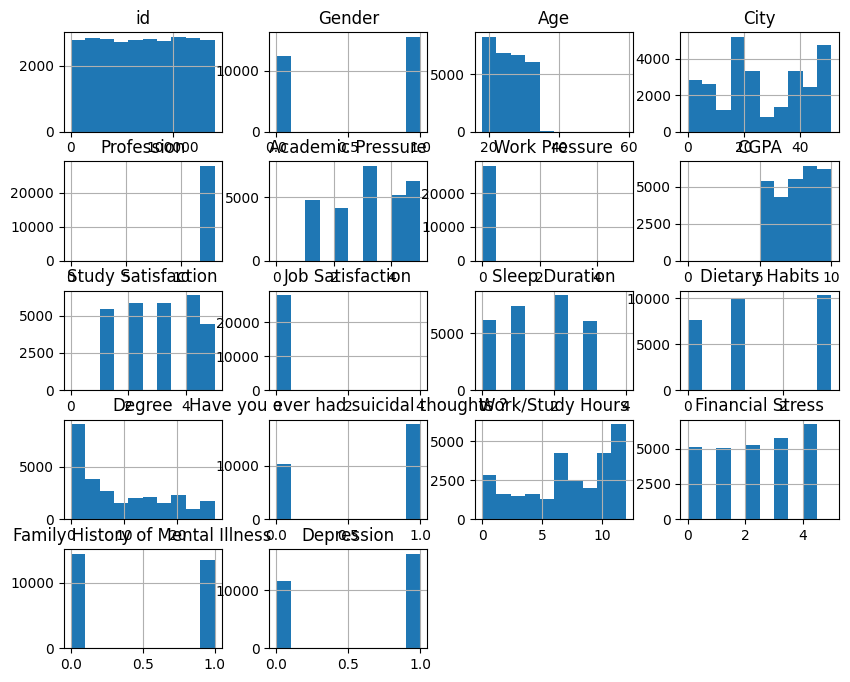

In [26]:
# Visualize the distributions of numeric columns
data.hist(figsize=(10, 8))
plt.show()

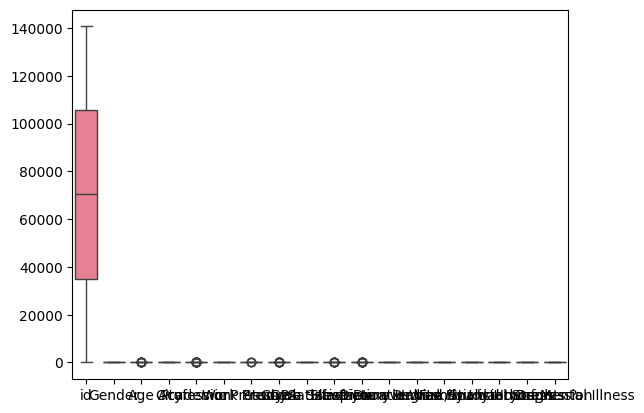

In [27]:
# Boxplot for identifying outliers
sns.boxplot(data=data)
plt.show()

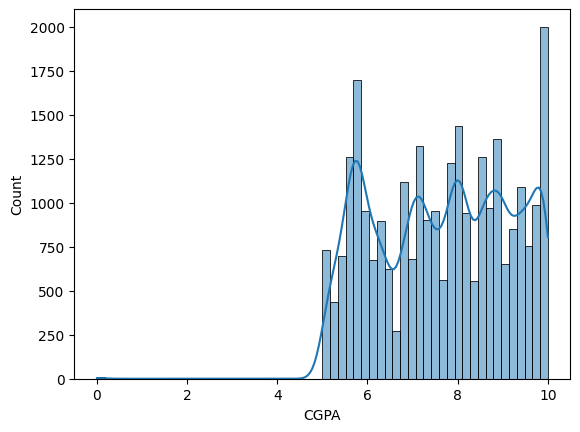

In [28]:
# Check for normality of a numeric variable (e.g., CGPA)
sns.histplot(data['CGPA'], kde=True)
plt.show()

In [29]:
# Shapiro-Wilk test for normality on the 'CGPA' column
_, p_value = stats.shapiro(data['CGPA'])
print(f"Shapiro-Wilk test p-value for CGPA: {p_value}")

Shapiro-Wilk test p-value for CGPA: 1.8169356707577128e-69


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 27901.
  res = hypotest_fun_out(*samples, **kwds)


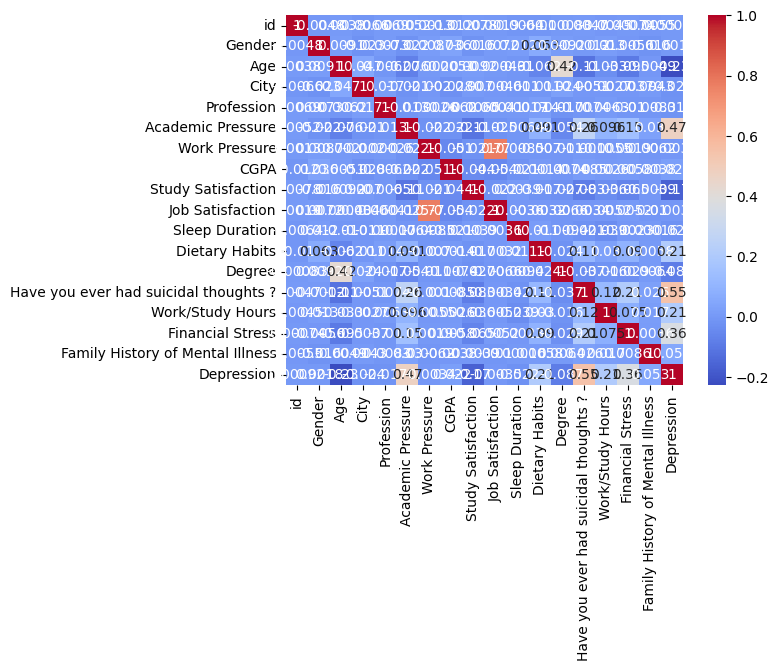

In [30]:
# Correlation matrix to identify relationships between numerical variables
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [31]:
# Handle outliers (if necessary, using Z-scores or removing them)
from scipy.stats import zscore

In [32]:
z_scores = zscore(data['CGPA'])
outliers = data[abs(z_scores) > 3]
print("Outliers based on Z-score:\n", outliers)

Outliers based on Z-score:
            id  Gender   Age  City  Profession  Academic Pressure  \
4365    21880       1  38.0     8          12                0.0   
10407   52737       1  28.0    48          12                3.0   
11489   58062       0  32.0    48          12                5.0   
13909   70453       0  20.0     4          12                0.0   
14855   75007       1  21.0    24          12                0.0   
20913  105773       1  18.0     4          12                0.0   
21805  110097       1  34.0    39          12                1.0   
25746  129756       1  18.0    40          12                0.0   
26719  134830       0  24.0    29          12                0.0   

       Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
4365             5.0   0.0                 0.0               4.0   
10407            0.0   0.0                 4.0               0.0   
11489            0.0   0.0                 0.0               0.0   
13909            0.

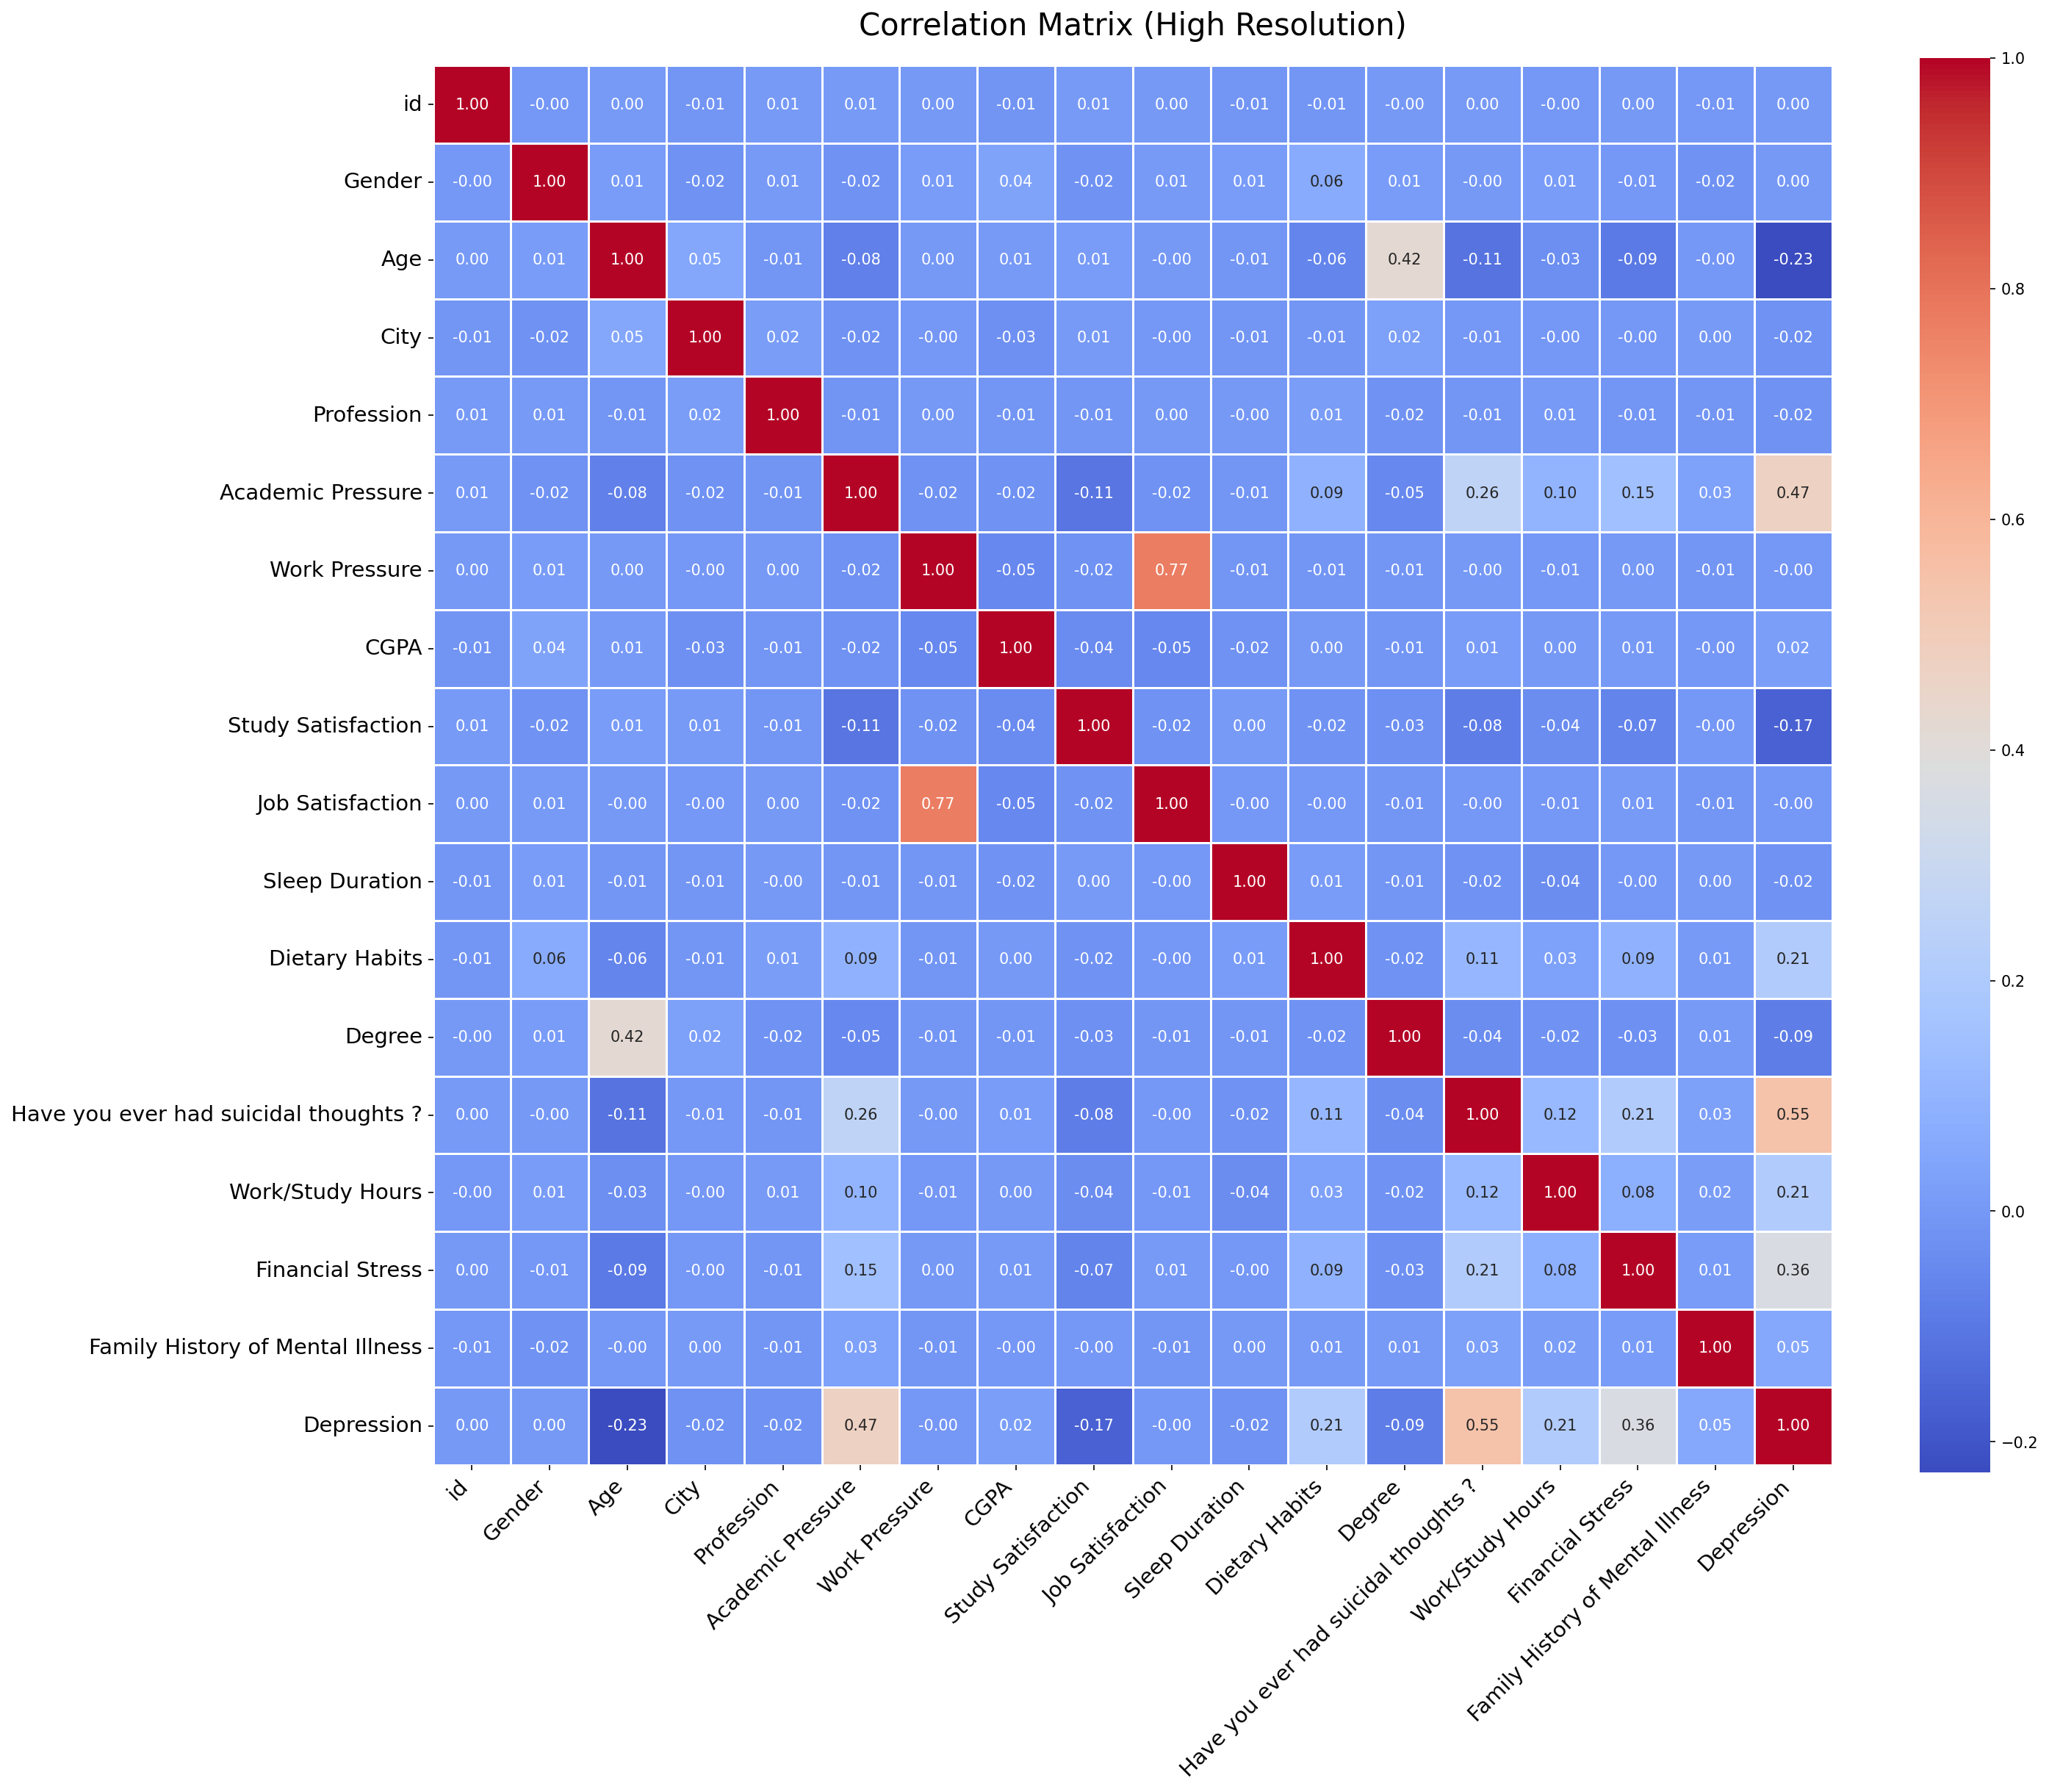

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# LabelEncode categorical variables
from sklearn.preprocessing import LabelEncoder
categorical_columns = ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree',
                       'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']

for col in categorical_columns:
    data[col] = LabelEncoder().fit_transform(data[col])

# Compute correlation matrix
corr = data.corr()

# Create large high-quality figure
plt.figure(figsize=(20, 20), dpi=150)

# Draw heatmap with big labels and numbers
sns.heatmap(
    corr,
    annot=True,      # 显示相关系数数值
    fmt=".2f",       # 小数点位数
    cmap="coolwarm", # 色系
    square=True,
    linewidths=0.5,  # 网格线
    cbar_kws={"shrink": .7} # 缩小 color bar
)

plt.xticks(fontsize=14, rotation=45, ha="right")
plt.yticks(fontsize=14)
plt.title("Correlation Matrix (High Resolution)", fontsize=20, pad=20)
plt.tight_layout()
plt.show()
